# Profitable Small-Caps — a quantitative teardown 🔬
### Excess-of-cash Sharpe races · paired Sharpe-difference bootstraps · HAC *t* on the daily difference · size/market beta decomposition · era cut · costed isolation trade · a planted-edge synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cleaned size premium, tradable?: Busted](https://img.shields.io/badge/Cleaned_size_premium%2C_tradable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is Asness-Frazzini-Israel-Moskowitz-Pedersen (2018): the size premium lives in profitable small caps once you control junk. The job here is to test whether a **long-only profitable-small-cap ETF** delivers a risk-adjusted edge over plain small caps (and large caps), and to separate any real edge from a mere small-cap/market beta and from costs.

> ⚠️ **Data note.** yfinance **total-return** closes; every leg is **excess of BIL** (the T-bill cash leg). The Sharpe race is sliced to the **common window** all five funds share (CALF is the youngest, 2017-06). Numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `3ec88092fc34`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from profitable_small import data, strategy as st

XLEGS = {"CALF": "x_CALF", "XSHQ": "x_XSHQ", "IWM": "x_IWM", "IJR": "x_IJR", "SPY": "x_SPY"}
RLEGS = {"CALF": "r_CALF", "XSHQ": "r_XSHQ", "IWM": "r_IWM", "IJR": "r_IJR", "SPY": "r_SPY"}
COLOR = {"CALF": GREEN, "XSHQ": "#2f9e6f", "IWM": GREY, "IJR": "#6f7a86", "SPY": RED}

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    FRAME = data.daily_frame(PRICES, asof=data.AS_OF)
else:
    PRICES = FRAME = None
print("real tape cached:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '3ec88092fc34', 'window': '2017-06-20 -> 2026-06-30', 'n_race': 2269, 'race': {'CALF': {'exc': 10.2, 'vol': 25.97, 'sr': 0.393, 'dd': -49.2, 'kind': 'profitable small'}, 'XSHQ': {'exc': 8.99, 'vol': 22.86, 'sr': 0.393, 'dd': -40.2, 'kind': 'profitable small'}, 'IWM': {'exc': 10.11, 'vol': 23.78, 'sr': 0.425, 'dd': -43.0, 'kind': 'plain small'}, 'IJR': {'exc': 10.21, 'vol': 23.6, 'sr': 0.433, 'dd': -46.1, 'kind': 'plain small (earnings screen)'}, 'SPY': {'exc': 13.31, 'vol': 18.68, 'sr': 0.712, 'dd': -33.9, 'kind': 'large cap'}}, 'boot': {'CALF': (0.393, -0.234, 0.997, 0.108), 'XSHQ': (0.393, -0.209, 0.994, 0.094), 'IWM': (0.425, -0.209, 1.081, 0.099), 'IJR': (0.433, -0.204, 1.073, 0.089), 'SPY': (0.712, 0.109, 1.406, 0.012)}, 'pairs': {'CALF vs IWM': (0.393, 0.425, -0.033, -0.323, 0.238, 0.584, 0.033, 0.02), 'CALF vs IJR': (0.393, 0.433, -0.04, -0.274, 0.17, 0.643, -0.004, -0.0), 'CALF vs SPY': (0.393, 0.712, -0.32, -0.76, 0.063, 0.946, -1.235, -0.6), 'XSHQ vs IWM': (0.396, 0.434, -0.039, -0.286, 0.193, 0.627, -0.509, -0.43), 'XSHQ vs IJR': (0.396, 0.438, -0.043, -0.252, 0.135, 0.671, -0.516, -0.54), 'XSHQ vs SPY': (0.396, 0.73, -0.334, -0.724, 0.026, 0.961, -1.805, -1.1)}, 'decomp': {'CALF': {'alpha': 0.93, 't': 0.27, 'b_iwm': 1.059, 't_iwm': 33.1, 'b_spy': -0.108, 't_spy': -2.8, 'r2': 0.816}, 'XSHQ': {'alpha': 0.73, 't': 0.26, 'b_iwm': 0.887, 't_iwm': 36.6, 'b_spy': -0.063, 't_spy': -1.6, 'r2': 0.773}}, 'era': {'pre': ('2017-06-20', '2020-12-31', 891, 0.364, 0.499, -0.135), 'post': ('2021-01-04', '2026-06-30', 1378, 0.419, 0.373, 0.045)}, 'cy': {2017: [5.8, 9.4, 9.1, 10.2, 10.2], 2018: [-10.1, -6.1, -11.1, -8.5, -4.6], 2019: [18.2, 17.4, 25.4, 22.8, 31.2], 2020: [16.6, 11.8, 20.0, 11.3, 18.3], 2021: [40.7, 24.0, 14.5, 26.6, 28.7], 2022: [-15.2, -15.0, -20.5, -16.2, -18.2], 2023: [35.4, 23.9, 16.8, 16.1, 26.2], 2024: [-7.4, 7.5, 11.4, 8.6, 24.9], 2025: [2.3, 0.9, 12.7, 5.9, 17.7], 2026: [14.3, 15.4, 22.6, 24.0, 10.1]}, 'costed': {'CALF': (0.45, 0.393, 0.375, 0.425, -0.05), 'XSHQ': (0.15, 0.396, 0.389, 0.434, -0.045)}, 'iso': {'CALF': (0.08, 0.02, -0.62, -0.18, 0.7), 'XSHQ': (-1.28, -0.43, -1.98, -0.67, 0.7)}, 'syn': [(0.0, -0.006, -0.301, 0.284, -0.26), (0.4, 0.425, 0.133, 0.718, 2.57)], 'ers': {'CALF': 0.59, 'XSHQ': 0.29, 'IWM': 0.19, 'IJR': 0.06, 'SPY': 0.09, 'BIL': 0.14}}


real tape cached: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Profitable small (CALF/XSHQ) excess-Sharpe **0.39** < plain IWM/IJR **0.42/0.43** < SPY **0.71**; every quality−plain Sharpe diff **negative**, CI straddles 0, HAC *t* ≈ 0; size/market α = **+0.9%/yr at *t* = 0.27** (β on IWM = 1.06); gap not era-robust (-0.135 → +0.045). |
| **Tradability** | `MIRAGE` | Costed net gap -0.050 Sharpe; long-quality/short-plain nets **-0.6%/yr (CALF)** / **-2.0%/yr (XSHQ)** after 0.70%/yr borrow+costs. |
| **Cleaned size premium, tradable?** | `BUSTED` | Large-cap SPY (Sharpe 0.71) beat every small-cap flavour, cleaned or not, 2017–2026. |

> 💡 In plain words: the ETF wrapper delivers small-cap beta, not a quality-cleaned premium. The AQR effect is a long-short cross-sectional result; a long-only fund can't harvest it, and the size premium simply wasn't paid this decade.

## 1 · The claim, steelmanned

AFMP (2018): let $r^{small}$, $r^{big}$ be size legs and $QMJ$ a quality-minus-junk factor. Raw $SMB = r^{small}-r^{big}$ is weak because small caps load *negatively* on QMJ (they're junkier). Controlling for it, the size coefficient in

$$r^{small}_t - r^{big}_t = a + b\,QMJ_t + \varepsilon_t$$

becomes large and stable — the 'cleaned' size premium is $a$. The **tradable** hypotheses:

- **H₁ (Sharpe).** A profitable-small ETF's **excess-of-cash Sharpe** > a plain-small ETF's, with a paired-bootstrap CI clear of zero and HAC *t* ≥ 2 on the daily return difference.
- **H₂ (cleaned alpha).** Regressing the quality leg on plain small caps and the market, the intercept $\alpha$ is **positive and significant** — a premium beyond size/market beta.
- **H₃ (robust).** The advantage holds across sub-eras and survives realistic costs.

Fail any of these on the live ETFs and the *tradable* version of the claim is not supported — whatever the underlying stock-level cross-section does.

## 2 · So what? — what rides on each answer

If H₁–H₃ hold, small-cap-quality ETFs are a free Sharpe upgrade over plain small caps and the AQR result is buyable off the shelf. If they fail, the funds are small-cap beta with a quality label and a bigger fee, and the honest small-cap tilt question collapses into 'small vs large', which large won this decade. Inference is **excess-of-cash throughout** (so cash-rate differences can't flatter anyone), **Newey-West HAC** on daily differences (fat tails, mild autocorrelation), and a **paired** block bootstrap on the Sharpe difference (the legs overlap day-by-day).

## 3 · How we'd know — the protocol

- **Universe.** CALF, XSHQ (profitable small) · IWM, IJR (plain small) · SPY (large) · BIL (cash). Total-return daily closes, as-of 2026-06-30 (partial month dropped).
- **Excess-of-cash.** Every leg minus BIL's daily total return.
- **Common window.** The Sharpe race is sliced to dates all five funds exist (2017-06-20 -> 2026-06-30, n = 2269); head-to-heads use each pair's own overlap.
- **Estimators.** Annualised excess-Sharpe; paired circular-block bootstrap of the Sharpe difference; HAC mean-*t* (10 daily lags) on the daily return difference; HAC OLS of the quality leg on `[x_IWM, x_SPY]`.
- **Eras.** Full sample · pre-2021 (incl. COVID) · 2021+.
- **Costs.** ER gap vs the plain baseline + 5 bps one-way on ~1 annual rebalance; the isolation trade adds 50 bps/yr borrow on the short leg.
- **Control.** `synthetic_world(edge)` plants a tunable quality edge over a shared small-cap factor plus a zero-mean junk drag; the null (edge = 0) must not fire.

## 4 · The teardown

### 4a · The Sharpe race and its uncertainty

Annualised excess-of-cash Sharpe on the common window, with a paired look at each quality-vs-plain and quality-vs-large match.

In [2]:
order = ['CALF','XSHQ','IWM','IJR','SPY']
if HAVE_REAL:
    r = st.race(FRAME, XLEGS)
    tab = [(k, r['legs'][k]['ann_excess_pct'], r['legs'][k]['ann_vol_pct'],
            r['legs'][k]['sharpe'], r['legs'][k]['maxdd_pct']) for k in order]
else:
    tab = [(k, R['race'][k]['exc'], R['race'][k]['vol'], R['race'][k]['sr'], R['race'][k]['dd']) for k in order]
print(f"{'leg':<6s} {'exc%/yr':>8s} {'vol%':>7s} {'Sharpe':>7s} {'maxDD%':>7s}")
for k,e,v,s,d in tab: print(f'{k:<6s} {e:>+8.2f} {v:>7.2f} {s:>+7.3f} {d:>+7.1f}')
print()
for m in ['CALF vs IWM','CALF vs IJR','CALF vs SPY','XSHQ vs IWM','XSHQ vs IJR','XSHQ vs SPY']:
    a, b = m.split(' vs ')
    if HAVE_REAL:
        p = st.pair_test(FRAME, XLEGS[a], XLEGS[b])
        vals = (p['sharpe_a'], p['sharpe_b'], p['sharpe_diff'], p['diff_ci_low'], p['diff_ci_high'], p['diff_frac_le0'], p['t_nw_diff'])
    else:
        z = R['pairs'][m]; vals = (z[0], z[1], z[2], z[3], z[4], z[5], z[7])
    print(f'{m:<12s} SR {vals[0]:+.3f} vs {vals[1]:+.3f}  diff {vals[2]:+.3f} '
          f'CI[{vals[3]:+.3f},{vals[4]:+.3f}] P(diff<=0)={vals[5]:.2f}  HAC t(daily)={vals[6]:+.2f}')

leg     exc%/yr    vol%  Sharpe  maxDD%
CALF     +10.20   25.97  +0.393   -49.2
XSHQ      +8.99   22.86  +0.393   -40.2
IWM      +10.11   23.78  +0.425   -43.0
IJR      +10.21   23.60  +0.433   -46.1
SPY      +13.31   18.68  +0.712   -33.9



CALF vs IWM  SR +0.393 vs +0.425  diff -0.033 CI[-0.323,+0.238] P(diff<=0)=0.58  HAC t(daily)=+0.02


CALF vs IJR  SR +0.393 vs +0.433  diff -0.040 CI[-0.274,+0.170] P(diff<=0)=0.64  HAC t(daily)=-0.00


CALF vs SPY  SR +0.393 vs +0.712  diff -0.320 CI[-0.760,+0.063] P(diff<=0)=0.95  HAC t(daily)=-0.60


XSHQ vs IWM  SR +0.396 vs +0.434  diff -0.039 CI[-0.286,+0.193] P(diff<=0)=0.63  HAC t(daily)=-0.43


XSHQ vs IJR  SR +0.396 vs +0.438  diff -0.043 CI[-0.252,+0.135] P(diff<=0)=0.67  HAC t(daily)=-0.54


XSHQ vs SPY  SR +0.396 vs +0.730  diff -0.334 CI[-0.724,+0.026] P(diff<=0)=0.96  HAC t(daily)=-1.10


> 💡 In plain words: profitable small caps land at Sharpe **0.39**, *below* plain small caps (**0.42/0.43**) and far below large-cap SPY (**0.71**). Every quality−plain difference is negative with a CI straddling zero and a daily-difference HAC *t* of essentially zero — **no edge, either direction**. Against SPY the loss is one-directional (P(diff ≤ 0) ≈ 0.95).

### 4b · Is there a cleaned alpha? — the size/market decomposition

$x^{quality}_t = \alpha + \beta_{1}\,x^{IWM}_t + \beta_{2}\,x^{SPY}_t + \varepsilon_t$, HAC standard errors. $\alpha$ is the daily excess return beyond small-cap and market beta.

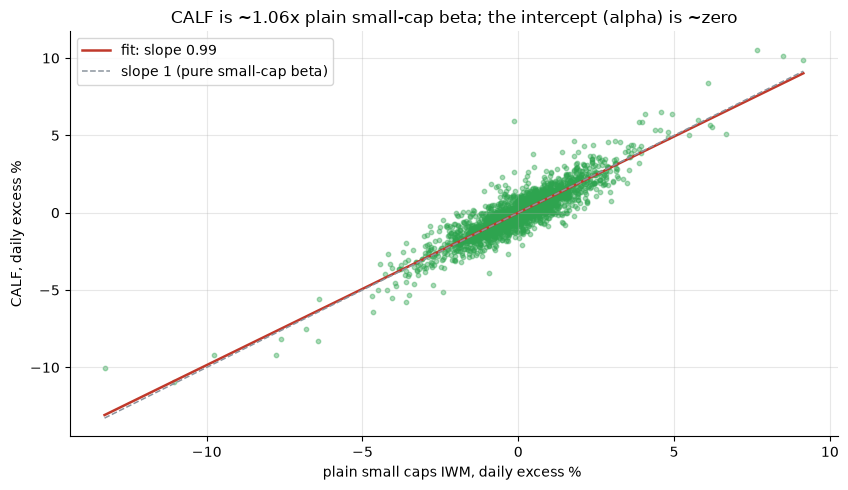

CALF: alpha +0.93%/yr (t=+0.27)  b_IWM=+1.059 (t=+33.1)  b_SPY=-0.108 (t=-2.8)  R2=0.816
XSHQ: alpha +0.73%/yr (t=+0.26)  b_IWM=+0.887 (t=+36.6)  b_SPY=-0.063 (t=-1.6)  R2=0.773


In [3]:
if HAVE_REAL:
    rows = []
    for k in ['CALF','XSHQ']:
        d = st.beta_decomp(FRAME, XLEGS[k], ['x_IWM','x_SPY'])
        rows.append((k, d['alpha_ann_pct'], d['t_alpha'], d['betas']['x_IWM'], d['t_betas']['x_IWM'],
                     d['betas']['x_SPY'], d['t_betas']['x_SPY'], d['r2']))
    d = st.beta_decomp(FRAME, 'x_CALF', ['x_IWM','x_SPY'])
    win = st.common_window(FRAME, ['x_CALF','x_IWM'])
    xs, ys = win['x_IWM'].to_numpy()*100, win['x_CALF'].to_numpy()*100
else:
    rows = [(k, R['decomp'][k]['alpha'], R['decomp'][k]['t'], R['decomp'][k]['b_iwm'], R['decomp'][k]['t_iwm'],
             R['decomp'][k]['b_spy'], R['decomp'][k]['t_spy'], R['decomp'][k]['r2']) for k in ['CALF','XSHQ']]
    rng = np.random.default_rng(901); xs = rng.normal(0, 1.5, 2269); ys = 1.06*xs + rng.normal(0.03, 0.7, 2269)
fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.scatter(xs, ys, s=10, alpha=.4, color=GREEN)
bfit = np.polyfit(xs, ys, 1); grid = np.linspace(xs.min(), xs.max(), 50)
ax.plot(grid, np.polyval(bfit, grid), c=RED, lw=1.8, label=f'fit: slope {bfit[0]:.2f}')
ax.plot(grid, grid, c=GREY, ls='--', lw=1.1, label='slope 1 (pure small-cap beta)')
ax.set_xlabel('plain small caps IWM, daily excess % '); ax.set_ylabel('CALF, daily excess %')
ax.set_title('CALF is ~1.06x plain small-cap beta; the intercept (alpha) is ~zero'); ax.legend()
plt.tight_layout(); plt.show()
for k,a,t,bi,ti,bs,ts,r2 in rows:
    print(f'{k}: alpha {a:+.2f}%/yr (t={t:+.2f})  b_IWM={bi:+.3f} (t={ti:+.1f})  b_SPY={bs:+.3f} (t={ts:+.1f})  R2={r2:.3f}')

> 💡 In plain words: CALF loads **1.06×** on plain small caps and leaves alpha **+0.9%/yr at HAC *t* = 0.27** — a statistical zero. XSHQ is the same story (0.89× IWM, α +0.7%/yr, *t* = 0.26). The negative small SPY beta just reflects the *large-minus-small* tilt inside a small-cap fund. **H₂ fails: no cleaned premium.**

### 4c · Era-robustness — the gap's sign flips

CALF vs IWM excess-Sharpe, split pre-/post-2021.

In [4]:
if HAVE_REAL:
    e = st.era_races(FRAME, {'CALF':'x_CALF','IWM':'x_IWM'}, split=data.ERA_SPLIT)
    rows = []
    for tag in ['pre','post']:
        rr = e[tag]; q, p = rr['legs']['CALF']['sharpe'], rr['legs']['IWM']['sharpe']
        rows.append((tag, rr['start'], rr['end'], rr['n'], q, p, q-p))
else:
    rows = [(tag, *R['era'][tag]) for tag in ['pre','post']]
for tag, s, en, n, q, p, g in rows:
    print(f'{tag:<4s} [{s}->{en} n={n}]  CALF SR {q:+.3f}  IWM SR {p:+.3f}  gap {g:+.3f}')

pre  [2017-06-20->2020-12-31 n=891]  CALF SR +0.364  IWM SR +0.499  gap -0.135
post [2021-01-04->2026-06-30 n=1378]  CALF SR +0.419  IWM SR +0.373  gap +0.045


> 💡 In plain words: the CALF−IWM Sharpe gap is **-0.135** before 2021 and **+0.045** after — it **flips sign** and both halves are inside the noise band. The opposite of the robust, pervasive, all-eras advantage AFMP document for the cleaned size premium in the underlying stocks. **H₃ fails.**

### 4d · Tradability — costs deepen a hole that starts at zero

(a) costed net Sharpe race (ER gap vs IWM + 5 bps one-way on one annual rebalance); (b) long-quality/short-plain isolation trade (50 bps/yr borrow + 5 bps one-way × 2/yr).

In [5]:
if HAVE_REAL:
    crows, irows = [], []
    for k in ['CALF','XSHQ']:
        c = st.costed_race(FRAME, XLEGS[k], 'x_IWM', er_quality=data.EXPENSE_RATIOS[k], er_plain=data.EXPENSE_RATIOS['IWM'])
        crows.append((k, c['charge_ann_pct'], c['sharpe_q_gross'], c['sharpe_q_net'], c['sharpe_plain'], c['net_gap']))
        it = st.isolation_trade(FRAME, XLEGS[k], 'x_IWM')
        irows.append((k, it['gross_ann_pct'], it['t_nw_gross'], it['net_ann_pct'], it['t_nw_net'], it['charge_ann_pct']))
else:
    crows = [(k, *R['costed'][k]) for k in ['CALF','XSHQ']]
    irows = [(k, *R['iso'][k]) for k in ['CALF','XSHQ']]
print('costed net Sharpe race vs IWM:')
for k, ch, g, n, iwm, gap in crows:
    print(f'  {k}: charge {ch:.2f}%/yr  Sharpe gross {g:+.3f} -> net {n:+.3f}  IWM {iwm:+.3f}  net gap {gap:+.3f}')
print('long-quality / short-plain isolation trade:')
for k, g, tg, n, tn, ch in irows:
    print(f'  {k}-IWM: gross {g:+.2f}%/yr (t={tg:+.2f})  net {n:+.2f}%/yr (t={tn:+.2f})  charge {ch:.2f}%/yr')

costed net Sharpe race vs IWM:
  CALF: charge 0.45%/yr  Sharpe gross +0.393 -> net +0.375  IWM +0.425  net gap -0.050
  XSHQ: charge 0.15%/yr  Sharpe gross +0.396 -> net +0.389  IWM +0.434  net gap -0.045
long-quality / short-plain isolation trade:
  CALF-IWM: gross +0.08%/yr (t=+0.02)  net -0.62%/yr (t=-0.18)  charge 0.70%/yr
  XSHQ-IWM: gross -1.28%/yr (t=-0.43)  net -1.98%/yr (t=-0.67)  charge 0.70%/yr


> 💡 In plain words: the costed net gap stays negative (-0.050 Sharpe for CALF), and the isolation trade — the purest way to bet 'quality beats junk' — earns nothing gross and loses **-0.6%/yr (CALF)** / **-2.0%/yr (XSHQ)** net. There is no edge for costs to erode; costs just make a zero negative. **MIRAGE.**

### 4e · Calendar-year returns — big swings, no compounding edge

      CALF  XSHQ   IWM   IJR   SPY
Date                              
2017   5.8   9.4   9.1  10.2  10.2
2018 -10.1  -6.1 -11.1  -8.5  -4.6
2019  18.2  17.4  25.4  22.8  31.2
2020  16.6  11.8  20.0  11.3  18.3
2021  40.7  24.0  14.5  26.6  28.7
2022 -15.2 -15.0 -20.5 -16.2 -18.2
2023  35.4  23.9  16.8  16.1  26.2
2024  -7.4   7.5  11.4   8.6  24.9
2025   2.3   0.9  12.7   5.9  17.7
2026  14.3  15.4  22.6  24.0  10.1


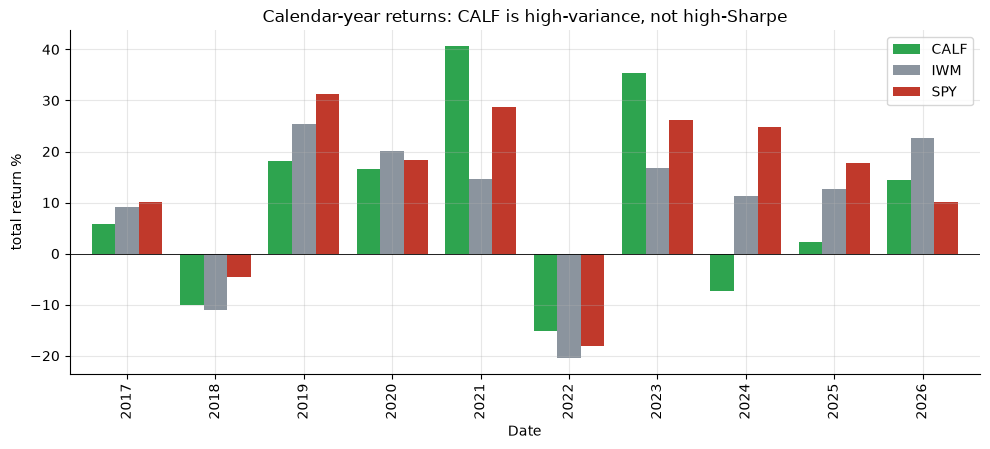

In [6]:
order = ['CALF','XSHQ','IWM','IJR','SPY']
if HAVE_REAL:
    cy = st.calendar_years(FRAME, RLEGS)[order]
else:
    cy = pd.DataFrame(R['cy'], index=order).T
print(cy.round(1).to_string())
fig, ax = plt.subplots(figsize=(10, 4.6))
cy[['CALF','IWM','SPY']].plot(kind='bar', ax=ax, color=[GREEN, GREY, RED], width=.8)
ax.axhline(0, c='k', lw=.6); ax.set_ylabel('total return %'); ax.set_title('Calendar-year returns: CALF is high-variance, not high-Sharpe')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: CALF's cash-flow screen is really a *value* tilt — a huge 2021 (+41 %) and 2023 (+35 %), an ugly 2024–2025. The years swing hard but don't stack into a superior risk-adjusted return; the volatility eats the occasional big win.

### 4f · Faithful-engine control — we know the truth here

Deterministic world: quality = market + small-cap factor + **planted edge**; plain = same systematic exposure + a zero-mean **junk** noise. The estimator must recover the knob; the zero-edge null must NOT fire. *(Machinery proof — never market evidence.)*

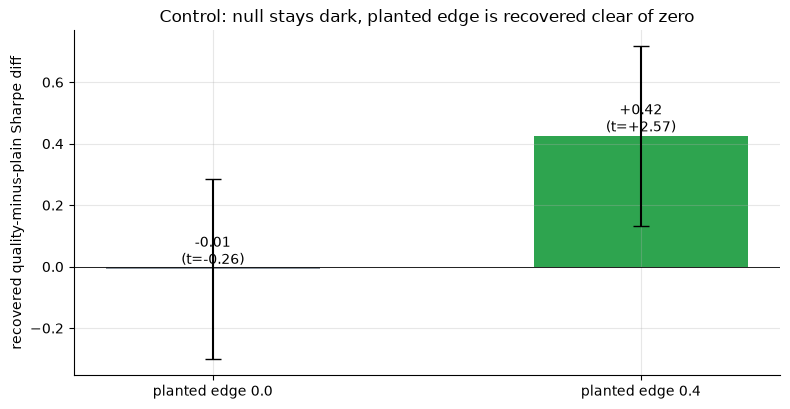

planted edge 0.0 -> Sharpe diff -0.006 CI[-0.301,+0.284] HAC t(daily)=-0.26
planted edge 0.4 -> Sharpe diff +0.425 CI[+0.133,+0.718] HAC t(daily)=+2.57


In [7]:
res = []
for edge in (0.0, 0.4):
    w = data.synthetic_world(edge=edge, seed=901)
    fr = pd.DataFrame({'x_quality': w['x_quality'], 'x_plain': w['x_plain']}, index=w.index)
    p = st.pair_test(fr, 'x_quality', 'x_plain')
    res.append((edge, p['sharpe_diff'], p['diff_ci_low'], p['diff_ci_high'], p['t_nw_diff']))
fig, ax = plt.subplots(figsize=(8.0, 4.2))
labels = [f'planted edge {e:.1f}' for e,_,_,_,_ in res]
diffs = [r[1] for r in res]; err = [[r[1]-r[2] for r in res],[r[3]-r[1] for r in res]]
ax.bar(labels, diffs, color=[GREY, GREEN], width=.5, yerr=err, capsize=6)
for i,(e,d,lo,hi,t) in enumerate(res): ax.annotate(f'{d:+.2f}\n(t={t:+.2f})',(i,d),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.6); ax.set_ylabel('recovered quality-minus-plain Sharpe diff')
ax.set_title('Control: null stays dark, planted edge is recovered clear of zero'); plt.tight_layout(); plt.show()
for e,d,lo,hi,t in res: print(f'planted edge {e:.1f} -> Sharpe diff {d:+.3f} CI[{lo:+.3f},{hi:+.3f}] HAC t(daily)={t:+.2f}')

> 💡 In plain words: with **no** planted edge the estimator reads Sharpe-diff **-0.006** (HAC *t* = -0.26, CI straddles zero); a planted **+0.4** comes back as **+0.425** with a CI clear of zero and HAC *t* = +2.57. The machinery detects a real edge when one exists — so the real-tape null (Sharpe diff ≈ 0, *t* ≈ 0) is the genuine reading, not a dead detector.

## 5 · The verdict

- **Signal `NONE`** — profitable-small excess-Sharpe **0.39** < plain **0.42/0.43** < SPY **0.71**; every quality−plain Sharpe diff negative with CI over zero and HAC *t* ≈ 0; size/market α = +0.9%/yr (*t* = 0.27), β on IWM ≈ 1.06; gap not era-robust (-0.135 → +0.045). The synthetic control recovers a planted edge cleanly, so this is a true null.
- **Tradability `MIRAGE`** — no edge to bank; costed net gap -0.050 Sharpe, isolation trade -0.6%/yr (CALF) net; CALF's 0.59% ER is a standing drag against a 0.06–0.19% plain baseline.
- **Cleaned size premium, tradable? `BUSTED`** — SPY (Sharpe 0.71) beat every small-cap flavour 2017–2026. The long-only ETF wrapper can't short the junk, so it never isolates the AFMP premium — it just holds nicer small caps that rose and fell with the tide.

## 6 · Going further

- **Long-short is the missing ingredient.** AFMP's cleaned premium is long profitable-small / **short junky-small**. A long-only ETF holds only the long leg, so it keeps full small-cap beta and never isolates $\alpha$. Our isolation trade approximates the short leg (short IWM) and finds nothing — but IWM is *all* small caps, not the junk tail specifically, so even this understates how hard the real long-short is to run in ETFs.
- **CALF ≈ small value.** The FCF-yield screen is a value tilt; its edge and drawdowns track value's fortunes, not a stable quality premium.
- **Dedup on the desk.** [513-size-effect](../../513-size-effect/README.md) (raw small-minus-big), [657-larry-portfolio](../../657-larry-portfolio/README.md) (small-**value**), [242-quality-minus-junk](../../242-quality-minus-junk/README.md) (QMJ across all caps — this is its small-cap-ETF slice), [362-piotroski-f-score](../../362-piotroski-f-score/README.md) (single-name quality scoring).

*Frozen numbers: [`docs/results.md`](../docs/results.md); sources: [`docs/references.md`](../docs/references.md).*